In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import pointbiserialr, ttest_ind
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
from sklearn.preprocessing import RobustScaler



In [2]:
# Load the data from the uploaded Excel file
file_path = 'Balanced_Stock_Data.xlsx'
data = pd.read_excel(file_path)

In [3]:
data

,Saham,Sektor,Harga Close,Status Menyentuh 50,Tanggal Menyentuh 50,Quartal,PBVn-1,PBVn-2,PBVn-3,PBVn-4,...,QRn-3,QRn-4,DERn-1,DERn-2,DERn-3,DERn-4,WCRn-1,WCRn-2,WCRn-3,WCRn-4
0,INCF,Basic Materials,20,Ya,2019-11-07,4,0.51,2.19,3.07,2.68,...,0.81,0.89,1.98,2.04,2.01,2.07,0.98,0.97,1.11,1.11
1,KKES,Basic Materials,30,Ya,2023-09-20,3,1.61,2.37,3.04,3.65,...,1.47,1.18,0.10,0.11,0.04,0.01,2.01,2.00,2.37,2.09
2,ESIP,Basic Materials,23,Ya,2021-08-20,3,0.87,0.91,1.25,1.75,...,0.43,0.45,0.46,0.44,0.44,0.43,1.16,1.22,1.31,1.35
3,SWAT,Basic Materials,37,Ya,2022-12-05,4,0.80,0.86,1.11,1.93,...,1.00,0.93,1.50,1.39,1.33,1.29,1.30,1.37,1.41,1.39
4,NPGF,Basic Materials,36,Ya,2022-10-26,4,0.85,1.00,1.23,1.40,...,0.88,0.83,0.67,0.64,0.64,0.66,1.16,1.18,1.17,1.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,EKAD,Basic Materials,51,Tidak,2015-09-29,3,1.17,1.34,1.42,1.27,...,1.06,1.25,0.22,0.30,0.32,0.24,2.71,2.47,2.33,2.58
404,CTBN,Basic Materials,990,Tidak,2024-03-05,1,0.73,0.78,1.35,0.81,...,0.61,0.90,0.11,0.04,0.16,0.31,2.09,1.98,1.90,1.92
405,KRAS,Basic Materials,81,Tidak,2024-06-19,2,0.36,0.34,0.45,0.44,...,0.22,0.23,2.91,2.72,2.72,2.52,0.30,0.31,0.35,0.36
406,TALF,Basic Materials,201,Tidak,2020-07-15,3,0.35,0.33,0.38,0.60,...,1.34,1.44,0.19,0.18,0.14,0.19,2.16,2.17,2.70,2.72


In [4]:
# Select only financial indicators and the stock price for correlation analysis
financial_columns = [
    'PBVn-1', 'PBVn-2', 'PBVn-3', 'PBVn-4',
    'PTBVn-1', 'PTBVn-2', 'PTBVn-3', 'PTBVn-4',
    'CRn-1', 'CRn-2', 'CRn-3', 'CRn-4',
    'QRn-1', 'QRn-2', 'QRn-3', 'QRn-4',
    'DERn-1', 'DERn-2', 'DERn-3', 'DERn-4',
    'WCRn-1', 'WCRn-2', 'WCRn-3', 'WCRn-4'
]


# Update 'Status Binary' based on the new condition
data['Status Binary'] = data['Harga Close'].apply(lambda x: 1 if x > 50 else 0)

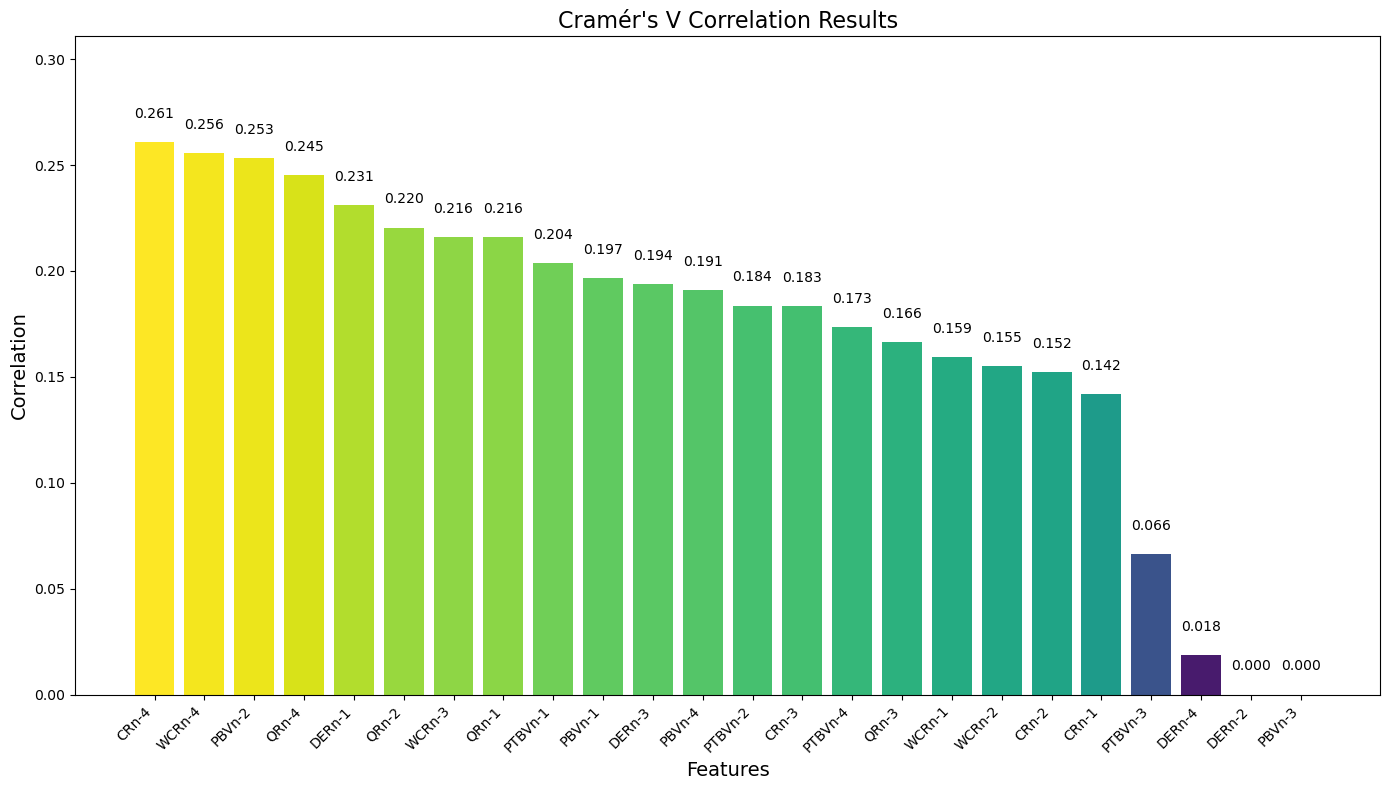

In [5]:
# Re-define the cramers_v function
def cramers_v(confusion_matrix):
    """Calculate Cramér's V for a given confusion matrix."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Re-calculate Cramér's V results for the dataset
cramers_results = {}
for feature in financial_columns:
    confusion_matrix = pd.crosstab(data[feature].round(2), data['Status Binary'])
    cramers_results[feature] = cramers_v(confusion_matrix.values)

# Convert results to DataFrame for visualization
cramers_results_df = pd.DataFrame(
    list(cramers_results.items()), columns=['Feature', "Cramér's V"]
).sort_values(by="Cramér's V", ascending=False)

# Extract features and Cramér's V values for plotting
features = cramers_results_df['Feature']
values = cramers_results_df["Cramér's V"]

# Visualize using matplotlib with vertical bars
plt.figure(figsize=(14, 8))
bars = plt.bar(features, values, color=plt.cm.viridis(values / max(values)))

# Annotate correlation values at the top of the bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# Customize the plot
plt.title("Cramér's V Correlation Results", fontsize=16)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Correlation", fontsize=14)
plt.ylim(0, max(values) + 0.05)  # Add some padding to the y-axis
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate feature labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Re-define the cramers_v function
def cramers_v(confusion_matrix):
    """Calculate Cramér's V for a given confusion matrix."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Re-calculate Cramér's V results for the dataset
cramers_results = {}
for feature in financial_columns:
    confusion_matrix = pd.crosstab(data[feature].round(2), data['Status Binary'])
    cramers_results[feature] = cramers_v(confusion_matrix.values)

# Convert results to DataFrame for visualization
cramers_results_df = pd.DataFrame(
    list(cramers_results.items()), columns=['Feature', "Cramér's V"]
).sort_values(by="Cramér's V", ascending=False)

# Select top 10 features
cramers_results_top10 = cramers_results_df.head(10)

# Extract features and Cramér's V values for plotting
features = cramers_results_top10['Feature']
values = cramers_results_top10["Cramér's V"]

# Visualize using matplotlib with vertical bars
plt.figure(figsize=(14, 8))
bars = plt.bar(features, values, color=plt.cm.viridis(values / max(values)))

# Annotate correlation values at the top of the bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# Customize the plot
plt.title("Top 10 Features by Cramér's V Correlation", fontsize=16)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Correlation", fontsize=14)
plt.ylim(0, max(values) + 0.05)  # Add some padding to the y-axis
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate feature labels for better readability
plt.tight_layout()

# Show the plot
plt.show()


In [6]:
# Convert results to DataFrame for visualization
cramers_results_df = pd.DataFrame(
    list(cramers_results.items()), columns=['Feature', "Cramér's V"]
).sort_values(by="Cramér's V", ascending=False)

# Display the DataFrame as a table
print(cramers_results_df)

# If needed, save the table to a CSV file
cramers_results_df.to_csv("cramers_v_results.csv", index=False)


    Feature  Cramér's V
11    CRn-4    0.260774
23   WCRn-4    0.255699
1    PBVn-2    0.253259
15    QRn-4    0.245197
16   DERn-1    0.230943
13    QRn-2    0.220436
22   WCRn-3    0.216080
12    QRn-1    0.215795
4   PTBVn-1    0.203874
0    PBVn-1    0.196780
18   DERn-3    0.193615
3    PBVn-4    0.190840
5   PTBVn-2    0.183603
10    CRn-3    0.183283
7   PTBVn-4    0.173315
14    QRn-3    0.166259
20   WCRn-1    0.159325
21   WCRn-2    0.155177
9     CRn-2    0.152151
8     CRn-1    0.141904
6   PTBVn-3    0.066461
19   DERn-4    0.018467
17   DERn-2    0.000000
2    PBVn-3    0.000000


In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from itertools import combinations
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ambil 10 fitur terbaik berdasarkan nilai Cramér's V
sorted_features = cramers_results_df.sort_values(by="Cramér's V", ascending=False)['Feature'].tolist()
selected_features = sorted_features[:10]

# Create feature matrix (X) dan target vector (y)
X = data[selected_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Simpan hasil untuk setiap kombinasi fitur
results = []

# Iterasi melalui semua kombinasi fitur
for r in range(1, len(selected_features) + 1):
    for feature_combination in combinations(selected_features, r):
        feature_combination = list(feature_combination)

        # Subset data dengan fitur terpilih
        X_train_subset = X_train[feature_combination]
        X_test_subset = X_test[feature_combination]

        # Latih model XGBoost
        xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        xgb.fit(X_train_subset, y_train)

        # Prediksi pada data testing
        y_test_pred = xgb.predict(X_test_subset)

        # Evaluasi performa
        accuracy = accuracy_score(y_test, y_test_pred)

        # Simpan hasil
        results.append({
            'Features': feature_combination,
            'Num Features': len(feature_combination),
            'Accuracy': accuracy
        })

# Convert hasil menjadi DataFrame
results_df = pd.DataFrame(results)

# Cari kombinasi fitur terbaik
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best Feature Combination:")
print(best_result)

# Tampilkan semua hasil
print("\nAll Results:")
print(results_df.sort_values(by='Accuracy', ascending=False))


c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:36:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:36:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:36:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\

Best Feature Combination:
Features        [CRn-4, WCRn-4, PBVn-2, QRn-4]
Num Features                                 4
Accuracy                              0.695122
Name: 175, dtype: object

All Results:
                                   Features  Num Features  Accuracy
388   [CRn-4, WCRn-4, PBVn-2, QRn-4, QRn-1]             5  0.695122
175          [CRn-4, WCRn-4, PBVn-2, QRn-4]             4  0.695122
390  [CRn-4, WCRn-4, PBVn-2, QRn-4, PBVn-1]             5  0.695122
187          [CRn-4, WCRn-4, QRn-4, PBVn-1]             4  0.695122
519  [WCRn-4, PBVn-2, QRn-4, QRn-2, PBVn-1]             5  0.695122
..                                      ...           ...       ...
164               [DERn-1, PTBVn-1, PBVn-1]             3  0.475610
332        [PBVn-2, DERn-1, QRn-2, PTBVn-1]             4  0.463415
34                          [QRn-4, DERn-1]             2  0.463415
43                        [DERn-1, PTBVn-1]             2  0.463415
339       [PBVn-2, DERn-1, PTBVn-1, PBVn-1]   

c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:37:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:37:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       163
           1       1.00      1.00      1.00       163

    accuracy                           1.00       326
   macro avg       1.00      1.00      1.00       326
weighted avg       1.00      1.00      1.00       326


Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.68      0.73      0.71        41
           1       0.71      0.66      0.68        41

    accuracy                           0.70        82
   macro avg       0.70      0.70      0.69        82
weighted avg       0.70      0.70      0.69        82



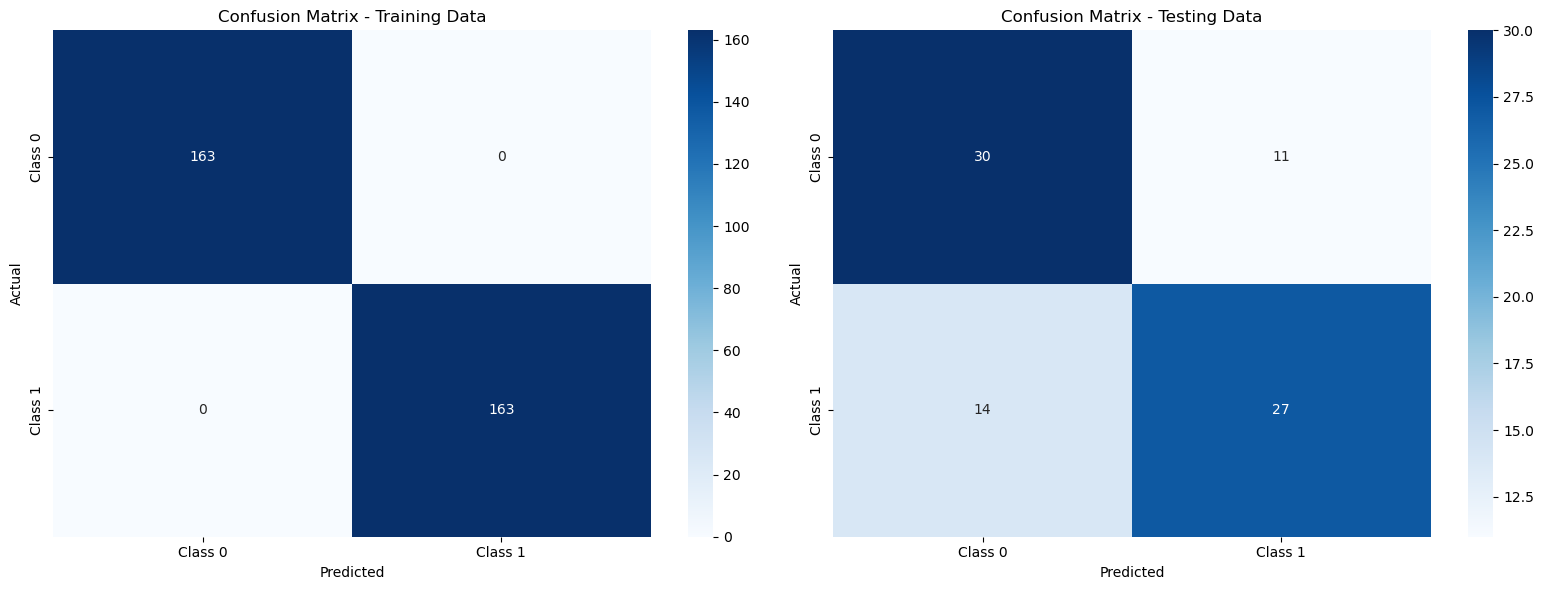

Train Accuracy: 1.00
Test Accuracy: 0.70


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Ambil kombinasi fitur terbaik dari output sebelumnya
best_features = ['CRn-4', 'WCRn-4', 'PBVn-2', 'QRn-4']

# Create feature matrix (X) dan target vector (y)
X = data[best_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Prediksi untuk training dan testing
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

# Classification Report
print("Classification Report (Training):")
print(classification_report(y_train, y_train_pred))
print("\nClassification Report (Testing):")
print(classification_report(y_test, y_test_pred))

# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix untuk Training
train_cm = confusion_matrix(y_train, y_train_pred)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"], ax=axes[0])
axes[0].set_title("Confusion Matrix - Training Data")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix untuk Testing
test_cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"], ax=axes[1])
axes[1].set_title("Confusion Matrix - Testing Data")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Cetak akurasi untuk training dan testing
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")


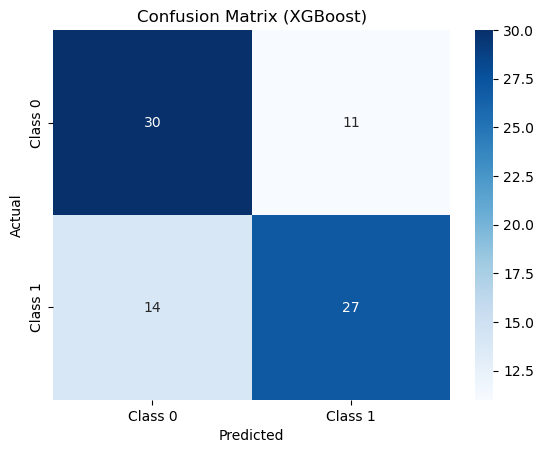

In [9]:
#Confusion Matrix untuk Testing Data XGBoost

# Confusion matrix untuk data testing
test_cm_xgb = confusion_matrix(y_test, y_test_pred)
sns.heatmap(test_cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from itertools import combinations
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ambil 10 fitur terbaik berdasarkan nilai Cramér's V
sorted_features = cramers_results_df.sort_values(by="Cramér's V", ascending=False)['Feature'].tolist()
selected_features = sorted_features[:10]

# Create feature matrix (X) dan target vector (y)
X = data[selected_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Simpan hasil untuk setiap kombinasi fitur
results = []

# Iterasi melalui semua kombinasi fitur
for r in range(1, len(selected_features) + 1):
    for feature_combination in combinations(selected_features, r):
        feature_combination = list(feature_combination)

        # Subset data dengan fitur terpilih
        X_train_subset = X_train[feature_combination]
        X_test_subset = X_test[feature_combination]

        # Latih model SVM
        svm = SVC(kernel='rbf', probability=True, random_state=42)
        svm.fit(X_train_subset, y_train)

        # Prediksi pada data testing
        y_test_pred = svm.predict(X_test_subset)

        # Evaluasi performa
        accuracy = accuracy_score(y_test, y_test_pred)

        # Simpan hasil
        results.append({
            'Features': feature_combination,
            'Num Features': len(feature_combination),
            'Accuracy': accuracy
        })

# Convert hasil menjadi DataFrame
results_df = pd.DataFrame(results)

# Cari kombinasi fitur terbaik
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best Feature Combination:")
print(best_result)

# Tampilkan semua hasil
print("\nAll Results:")
print(results_df.sort_values(by='Accuracy', ascending=False))


Best Feature Combination:
Features        [DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]
Num Features                                          5
Accuracy                                       0.707317
Name: 634, dtype: object

All Results:
                                           Features  Num Features  Accuracy
634         [DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]             5  0.707317
133                         [PBVn-2, QRn-2, PBVn-1]             3  0.695122
337                [PBVn-2, DERn-1, QRn-1, PTBVn-1]             4  0.682927
843  [QRn-4, DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]             6  0.682927
625         [QRn-4, DERn-1, QRn-1, PTBVn-1, PBVn-1]             5  0.682927
..                                              ...           ...       ...
100                         [WCRn-4, QRn-4, WCRn-3]             3  0.500000
550          [WCRn-4, QRn-4, DERn-1, WCRn-3, QRn-1]             5  0.500000
798   [WCRn-4, QRn-4, DERn-1, QRn-2, WCRn-3, QRn-1]             6  0.500000
286    

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import pandas as pd

# Ambil kombinasi fitur terbaik dari output sebelumnya
best_features = ['DERn-1', 'QRn-2', 'QRn-1', 'PTBVn-1', 'PBVn-1']

# Create feature matrix (X) dan target vector (y)
X = data[best_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define kernel types
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

# Simpan hasil untuk setiap kernel
results = []

for kernel in kernels:
    print(f"Evaluating SVM with {kernel} kernel...")

    # Train SVM dengan kernel saat ini
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train, y_train)

    # Prediksi pada data testing
    y_test_pred = svm.predict(X_test)

    # Hitung metrik untuk testing
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_test_pred)

    # Simpan hasil
    results.append({
        'Kernel': kernel,
        'Test Precision': precision,
        'Test Recall': recall,
        'Test F1-Score': f1,
        'Test Accuracy': accuracy
    })

# Convert hasil menjadi DataFrame untuk ditampilkan
results_df = pd.DataFrame(results)
print("\nSVM Kernel Performance:")
print(results_df)


Evaluating SVM with linear kernel...
Evaluating SVM with rbf kernel...
Evaluating SVM with poly kernel...
Evaluating SVM with sigmoid kernel...

SVM Kernel Performance:
    Kernel  Test Precision  Test Recall  Test F1-Score  Test Accuracy
0   linear        0.705686     0.609756       0.558249       0.609756
1      rbf        0.720430     0.707317       0.702899       0.707317
2     poly        0.250000     0.500000       0.333333       0.500000
3  sigmoid        0.323966     0.365854       0.325743       0.365854


c:\Users\akbar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 1, 'gamma': 0.1}
Classification Report (Training):
              precision    recall  f1-score   support

           0       0.68      0.63      0.65       163
           1       0.65      0.70      0.67       163

    accuracy                           0.66       326
   macro avg       0.66      0.66      0.66       326
weighted avg       0.66      0.66      0.66       326


Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        41
           1       0.69      0.76      0.72        41

    accuracy                           0.71        82
   macro avg       0.71      0.71      0.71        82
weighted avg       0.71      0.71      0.71        82



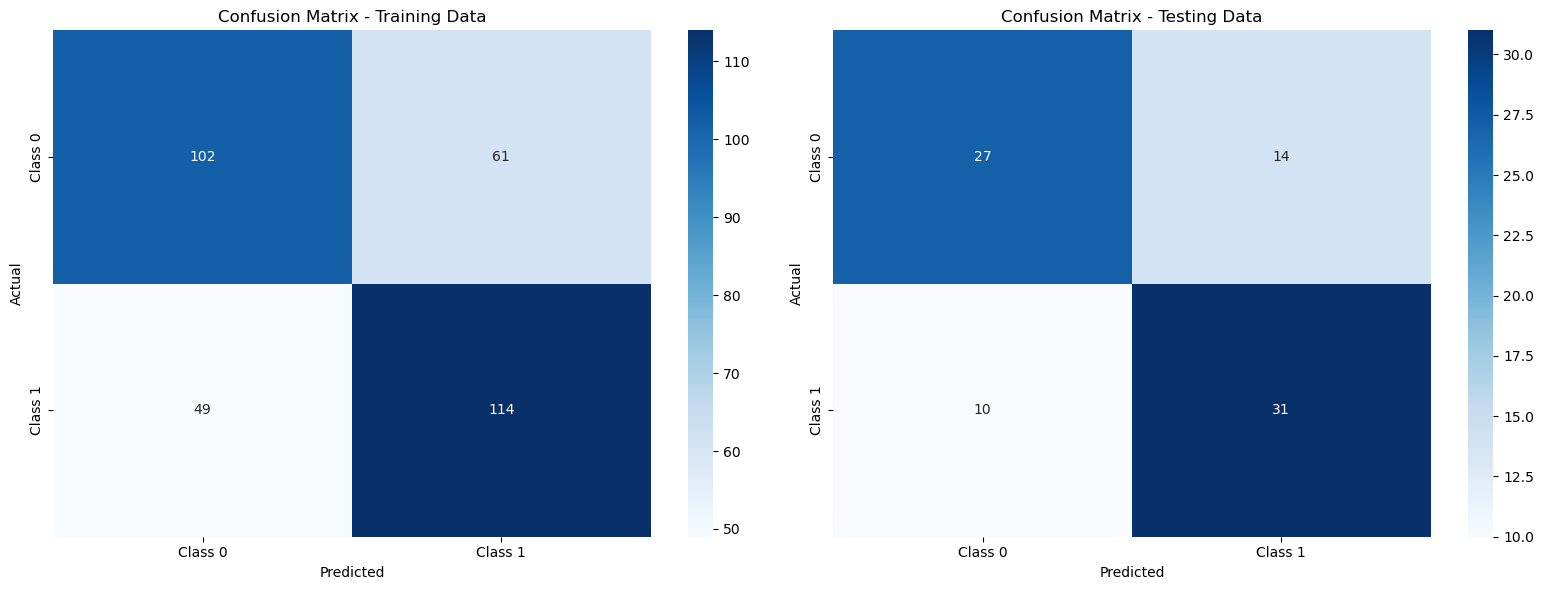

Train Accuracy: 0.66
Test Accuracy: 0.71


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

# Ambil kombinasi fitur terbaik dari output sebelumnya
best_features = ['DERn-1', 'QRn-2', 'QRn-1', 'PTBVn-1', 'PBVn-1']

# Create feature matrix (X) dan target vector (y)
X = data[best_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Hyperparameter tuning dengan GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid_search = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42), param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Model terbaik
best_svm_rbf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Prediksi untuk training dan testing
y_train_pred = best_svm_rbf.predict(X_train)
y_test_pred = best_svm_rbf.predict(X_test)

# Classification Report
print("Classification Report (Training):")
print(classification_report(y_train, y_train_pred))
print("\nClassification Report (Testing):")
print(classification_report(y_test, y_test_pred))

# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix untuk Training
train_cm = confusion_matrix(y_train, y_train_pred)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"], ax=axes[0])
axes[0].set_title("Confusion Matrix - Training Data")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix untuk Testing
test_cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"], ax=axes[1])
axes[1].set_title("Confusion Matrix - Testing Data")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Cetak akurasi untuk training dan testing
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")


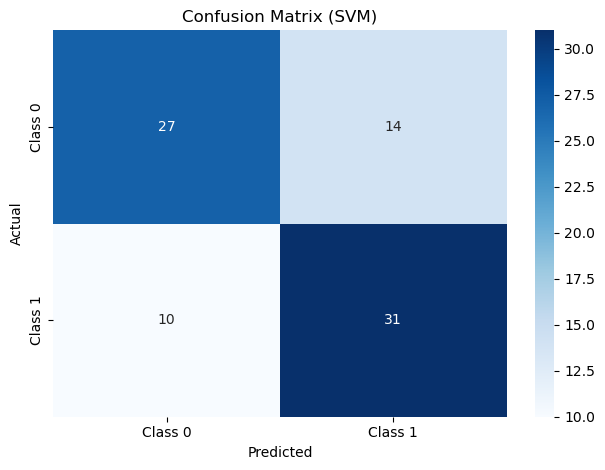

In [13]:
# **Confusion Matrix untuk Testing Data**
test_cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from itertools import combinations
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ambil 10 fitur terbaik berdasarkan nilai Cramér's V
sorted_features = cramers_results_df.sort_values(by="Cramér's V", ascending=False)['Feature'].tolist()
selected_features = sorted_features[:10]

# Create feature matrix (X) dan target vector (y)
X = data[selected_features]
y = data['Status Binary']

# Splitting data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Simpan hasil untuk setiap kombinasi fitur
results_svm = []
results_xgb = []

# Iterasi melalui semua kombinasi fitur
for r in range(1, len(selected_features) + 1):
    for feature_combination in combinations(selected_features, r):
        feature_combination = list(feature_combination)

        # Subset data dengan fitur terpilih
        X_train_subset = X_train[feature_combination]
        X_test_subset = X_test[feature_combination]

        # Latih model SVM
        svm = SVC(kernel='rbf', probability=True, random_state=42)
        svm.fit(X_train_subset, y_train)

        # Prediksi pada data testing (SVM)
        y_test_pred_svm = svm.predict(X_test_subset)

        # Evaluasi performa (SVM)
        accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

        # Simpan hasil (SVM)
        results_svm.append({
            'Method': 'SVM',
            'Features': feature_combination,
            'Num Features': len(feature_combination),
            'Accuracy': accuracy_svm
        })

        # Latih model XGBoost
        xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        xgb.fit(X_train_subset, y_train)

        # Prediksi pada data testing (XGBoost)
        y_test_pred_xgb = xgb.predict(X_test_subset)

        # Evaluasi performa (XGBoost)
        accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)

        # Simpan hasil (XGBoost)
        results_xgb.append({
            'Method': 'XGBoost',
            'Features': feature_combination,
            'Num Features': len(feature_combination),
            'Accuracy': accuracy_xgb
        })

# Convert hasil menjadi DataFrame
results_svm_df = pd.DataFrame(results_svm)
results_xgb_df = pd.DataFrame(results_xgb)

# Cari kombinasi fitur terbaik untuk SVM dan XGBoost
best_result_svm = results_svm_df.loc[results_svm_df['Accuracy'].idxmax()]
best_result_xgb = results_xgb_df.loc[results_xgb_df['Accuracy'].idxmax()]

print("Best Feature Combination (SVM):")
print(best_result_svm)

print("\nBest Feature Combination (XGBoost):")
print(best_result_xgb)

# Tampilkan semua hasil
print("\nAll Results (SVM):")
print(results_svm_df.sort_values(by='Accuracy', ascending=False))

print("\nAll Results (XGBoost):")
print(results_xgb_df.sort_values(by='Accuracy', ascending=False))


c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:38:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:38:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:38:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\akbar\anaconda3\Lib\site-packages\

Best Feature Combination (SVM):
Method                                              SVM
Features        [DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]
Num Features                                          5
Accuracy                                       0.707317
Name: 634, dtype: object

Best Feature Combination (XGBoost):
Method                                 XGBoost
Features        [CRn-4, WCRn-4, PBVn-2, QRn-4]
Num Features                                 4
Accuracy                              0.695122
Name: 175, dtype: object

All Results (SVM):
    Method                                        Features  Num Features  \
634    SVM         [DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]             5   
133    SVM                         [PBVn-2, QRn-2, PBVn-1]             3   
337    SVM                [PBVn-2, DERn-1, QRn-1, PTBVn-1]             4   
843    SVM  [QRn-4, DERn-1, QRn-2, QRn-1, PTBVn-1, PBVn-1]             6   
625    SVM         [QRn-4, DERn-1, QRn-1, PTBVn-1, PBVn-1]           

c:\Users\akbar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:40:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
